In [1]:
import pandas as pd
import numpy as np

import itertools

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
import itertools

from itertools import product

In [2]:
# Defind directory, sample, rounds, and Deduplication method
DIR = f"/scratch/users/taerim/projects/YiLu_DNAzyme/v1_clean/results/"

sample = "aKG"
rounds = [18, 19, 21]

Deduplication = "UseAll"
# Deduplication = "Deduplicate"

In [3]:
# Make a directory to save enrichment results
cmd = f"mkdir -p {DIR}/Enrichment/{sample}/{Deduplication}"
os.system(cmd)

0

In [4]:
# Read the motif/position frequency files for each round
df_1 = pd.read_csv(
    f"{DIR}/{sample}{rounds[0]}/{sample}{rounds[0]}_N40Seq_MotifPositionCount_{Deduplication}.tsv",
    sep="\t",
)
df_2 = pd.read_csv(
    f"{DIR}/{sample}{rounds[1]}/{sample}{rounds[1]}_N40Seq_MotifPositionCount_{Deduplication}.tsv",
    sep="\t",
)
df_3 = pd.read_csv(
    f"{DIR}/{sample}{rounds[2]}/{sample}{rounds[2]}_N40Seq_MotifPositionCount_{Deduplication}.tsv",
    sep="\t",
)

In [5]:
# Merge all rounds
df_merged = df_1.merge(
    df_2.loc[:, ["motif_position", "count"]],
    on=["motif_position"],
    suffixes=(f"_{rounds[0]}", f"_{rounds[1]}"),
)
df_merged = df_merged.merge(
    df_3.loc[:, ["motif_position", "count"]],
    on=["motif_position"],
    suffixes=("", f"_{rounds[2]}"),
)
df_merged.rename(columns={"count": f"count_{rounds[2]}"}, inplace=True)
df_merged.head()

,motif_position,motif,position,count_18,count_19,count_21
0,AAA_0,AAA,0,0,0,0
1,AAA_1,AAA,1,0,0,0
2,AAA_2,AAA,2,0,0,0
3,AAA_3,AAA,3,146,11,89
4,AAA_4,AAA,4,219,35,448


In [6]:
# Normalize count to relative frequency (count / total count)
df_merged_norm = df_merged.copy()
df_merged_norm[f"count_{rounds[0]}"] = (
    df_merged_norm[f"count_{rounds[0]}"] / df_merged_norm[f"count_{rounds[0]}"].sum()
)
df_merged_norm[f"count_{rounds[1]}"] = (
    df_merged_norm[f"count_{rounds[1]}"] / df_merged_norm[f"count_{rounds[1]}"].sum()
)
df_merged_norm[f"count_{rounds[2]}"] = (
    df_merged_norm[f"count_{rounds[2]}"] / df_merged_norm[f"count_{rounds[2]}"].sum()
)
df_merged_norm.head()

,motif_position,motif,position,count_18,count_19,count_21
0,AAA_0,AAA,0,0.000000,0.000000,0.000000
1,AAA_1,AAA,1,0.000000,0.000000,0.000000
2,AAA_2,AAA,2,0.000000,0.000000,0.000000
3,AAA_3,AAA,3,0.000003,0.000002,0.000002
4,AAA_4,AAA,4,0.000005,0.000006,0.000009


In [7]:
# lineplot (rounds), y: count, hue: motif_position)
df_melted = df_merged_norm.melt(
    id_vars=["motif_position"],
    value_vars=[f"count_{rounds[0]}", f"count_{rounds[1]}", f"count_{rounds[2]}"],
    var_name="round",
    value_name="count",
)
df_melted["round"] = df_melted["round"].str.replace("count_", "round")
df_melted.head()

,motif_position,round,count
0,AAA_0,round18,0.000000
1,AAA_1,round18,0.000000
2,AAA_2,round18,0.000000
3,AAA_3,round18,0.000003
4,AAA_4,round18,0.000005


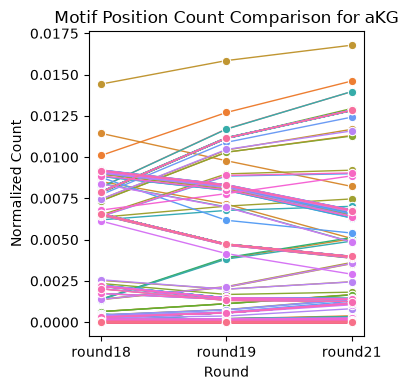

In [8]:
plt.figure(figsize=(4, 4))
sns.lineplot(
    data=df_melted, x="round", y="count", hue="motif_position", marker="o", linewidth=1
)
plt.title(f"Motif Position Count Comparison for {sample}")
plt.xlabel("Round")
plt.ylabel("Normalized Count")
# remove legend
plt.legend().remove()
plt.tight_layout()

# plt.savefig(f"{DIR}/Enrichment/{sample}/{sample}_GridEnrichment_All.png", dpi=300)

In [9]:
df_merged_norm[f"Diff_{rounds[0]}_to_{rounds[1]}"] = (
    df_merged_norm[f"count_{rounds[1]}"] - df_merged_norm[f"count_{rounds[0]}"]
)
df_merged_norm[f"Diff_{rounds[1]}_to_{rounds[2]}"] = (
    df_merged_norm[f"count_{rounds[2]}"] - df_merged_norm[f"count_{rounds[1]}"]
)


# threshold for consecutive increase
min_threshold = 0.001

# rule for consecutive increase:
df_merged_norm["Direction"] = df_merged_norm.apply(
    lambda row: (
        "Increase"
        if row[f"Diff_{rounds[0]}_to_{rounds[1]}"] > 0
        and row[f"Diff_{rounds[1]}_to_{rounds[2]}"] > 0
        and row[f"count_{rounds[0]}"] > min_threshold
        else "No Increase"
    ),
    axis=1,
)
df_merged_norm.head()

,motif_position,motif,position,count_18,count_19,count_21,Diff_18_to_19,Diff_19_to_21,Direction
0,AAA_0,AAA,0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,No Increase
1,AAA_1,AAA,1,0.000000,0.000000,0.000000,0.000000,0.000000e+00,No Increase
2,AAA_2,AAA,2,0.000000,0.000000,0.000000,0.000000,0.000000e+00,No Increase
3,AAA_3,AAA,3,0.000003,0.000002,0.000002,-0.000001,-1.922804e-07,No Increase
4,AAA_4,AAA,4,0.000005,0.000006,0.000009,0.000001,2.620940e-06,No Increase


## consecutive increase

In [10]:
df_melted_direction = df_merged_norm.melt(
    id_vars=["motif_position", "Direction"],
    value_vars=[f"count_{rounds[0]}", f"count_{rounds[1]}", f"count_{rounds[2]}"],
    var_name="round",
    value_name="count",
)
df_melted_direction["round"] = df_melted_direction["round"].str.replace(
    "count_", "round"
)
df_melted_direction.head()

,motif_position,Direction,round,count
0,AAA_0,No Increase,round18,0.000000
1,AAA_1,No Increase,round18,0.000000
2,AAA_2,No Increase,round18,0.000000
3,AAA_3,No Increase,round18,0.000003
4,AAA_4,No Increase,round18,0.000005


In [11]:
df_melted_direction["Direction"].value_counts() / 3

Direction
No Increase    2388.0
Increase         44.0
Name: count, dtype: float64

<Figure size 400x400 with 0 Axes>

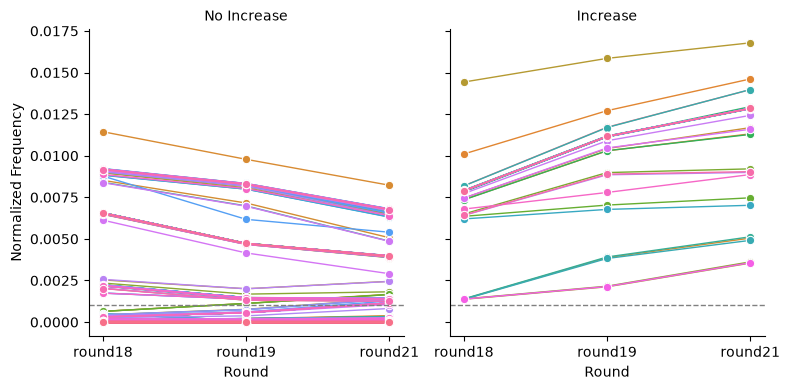

In [12]:
plt.figure(figsize=(4, 4))
# line plot facet by Direction (Increase vs No Increase) using map
g = sns.FacetGrid(df_melted_direction, col="Direction", height=4, aspect=1)
g.map(sns.lineplot, "round", "count", "motif_position", marker="o", linewidth=1)
# add horizontal line at y=min_threshold
for ax in g.axes.flat:
    ax.axhline(y=min_threshold, color="gray", linestyle="--", linewidth=1)
g.set_axis_labels("Round", "Normalized Frequency")
g.set_titles(col_template="{col_name}")
# g.add_legend(title="Motif Position", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().remove()
plt.tight_layout()

plt.savefig(
    f"{DIR}/Enrichment/{sample}/{Deduplication}/{sample}_GridEnrichment_IncDec_{Deduplication}.png",
    dpi=200,
)

In [13]:
df_direction = df_1.loc[:, ["motif_position", "motif", "position"]].merge(
    df_melted_direction.loc[:, ["motif_position", "Direction"]], on="motif_position"
)
df_direction.drop_duplicates(inplace=True)
df_direction["Direction_val"] = df_direction["Direction"].apply(
    lambda x: 1 if x == "Increase" else 0
)
print(df_direction.shape)
df_direction.head()

(2432, 5)


,motif_position,motif,position,Direction,Direction_val
0,AAA_0,AAA,0,No Increase,0
3,AAA_1,AAA,1,No Increase,0
6,AAA_2,AAA,2,No Increase,0
9,AAA_3,AAA,3,No Increase,0
12,AAA_4,AAA,4,No Increase,0


In [14]:
df_direction_2d = df_direction.pivot(
    index="motif", columns="position", values="Direction_val"
)
df_direction_2d.columns = df_direction_2d.columns + 1
df_direction_2d.head()

position,1,2,3,4,5,6,7,8,9,10,...,29,30,31,32,33,34,35,36,37,38
motif,,,,,,,,,,,,,,,,,,,,,
AAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
AAC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
ACA,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [15]:
# Save the 2D grid of motif and positions where the motif shows an increase in frequency across rounds. (0: No Increase, 1: Increase)
df_direction_2d.to_csv(
    f"{DIR}/Enrichment/{sample}/{Deduplication}/{sample}_GridEnrichment_2D_{Deduplication}.tsv",
    sep="\t",
)

In [16]:
tt = df_direction_2d.sum(axis=0)
pos_zero = tt[tt == 0].index.tolist()
pos_once = tt[tt == 1].index.tolist()
pos_multiple = tt[tt > 1].index.tolist()

print(f"Positions with zero increase: {pos_zero}")
print(f"Positions with one increase: {pos_once}")
print(f"Positions with multiple increases: {pos_multiple}")

Positions with zero increase: []
Positions with one increase: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 26, 27, 28, 29, 30, 31, 32, 36, 37, 38]
Positions with multiple increases: [23, 24, 25, 33, 34, 35]


In [17]:
# Define empty dictionary to store possible bases by position
possible_bases_by_position_N40 = {}
for pos in range(1, 41):
    possible_bases_by_position_N40[f"N40_Pos{pos}"] = []

# Add bases to the dictionary based on the motif positions that show an increase
for pos in df_direction_2d.columns:
    df_tmp = df_direction_2d.iloc[:, pos - 1]
    df_tmp = df_tmp[df_tmp > 0]
    for x in df_tmp.index:
        possible_bases_by_position_N40[f"N40_Pos{pos}"].append(x[0])
        possible_bases_by_position_N40[f"N40_Pos{pos+1}"].append(x[1])
        possible_bases_by_position_N40[f"N40_Pos{pos+2}"].append(x[2])

# Keep unique bases for each position
for pos in range(1, 41):
    list_tmp = list(set(possible_bases_by_position_N40[f"N40_Pos{pos}"]))
    list_tmp.sort()
    if len(list_tmp) == 0:
        list_tmp.append("-")
    possible_bases_by_position_N40[f"N40_Pos{pos}"] = list_tmp

possible_bases_by_position_N40

{'N40_Pos1': ['A'],
 'N40_Pos2': ['G'],
 'N40_Pos3': ['G'],
 'N40_Pos4': ['C'],
 'N40_Pos5': ['A'],
 'N40_Pos6': ['T'],
 'N40_Pos7': ['A'],
 'N40_Pos8': ['G'],
 'N40_Pos9': ['C'],
 'N40_Pos10': ['G'],
 'N40_Pos11': ['A'],
 'N40_Pos12': ['G'],
 'N40_Pos13': ['G'],
 'N40_Pos14': ['G'],
 'N40_Pos15': ['A'],
 'N40_Pos16': ['A'],
 'N40_Pos17': ['T'],
 'N40_Pos18': ['T'],
 'N40_Pos19': ['G'],
 'N40_Pos20': ['G'],
 'N40_Pos21': ['C'],
 'N40_Pos22': ['T'],
 'N40_Pos23': ['A'],
 'N40_Pos24': ['T'],
 'N40_Pos25': ['A', 'G'],
 'N40_Pos26': ['G'],
 'N40_Pos27': ['T'],
 'N40_Pos28': ['A'],
 'N40_Pos29': ['C'],
 'N40_Pos30': ['A'],
 'N40_Pos31': ['C'],
 'N40_Pos32': ['A'],
 'N40_Pos33': ['G'],
 'N40_Pos34': ['A'],
 'N40_Pos35': ['C', 'T'],
 'N40_Pos36': ['G'],
 'N40_Pos37': ['A'],
 'N40_Pos38': ['A'],
 'N40_Pos39': ['A'],
 'N40_Pos40': ['T']}

In [18]:
# Make every possible 40-mer sequence using the possible bases by position
all_possible_40mers = [
    "".join(p)
    for p in product(
        *[possible_bases_by_position_N40[f"N40_Pos{pos}"] for pos in range(1, 41)]
    )
]
all_possible_40mers

['AGGCATAGCGAGGGAATTGGCTATAGTACACAGACGAAAT',
 'AGGCATAGCGAGGGAATTGGCTATAGTACACAGATGAAAT',
 'AGGCATAGCGAGGGAATTGGCTATGGTACACAGACGAAAT',
 'AGGCATAGCGAGGGAATTGGCTATGGTACACAGATGAAAT']

In [19]:
# write the possible 40-mers to a file
with open(
    f"{DIR}/Enrichment/{sample}/{Deduplication}/{sample}_Enriched_N40_Sequences_{Deduplication}.txt",
    "w",
) as f:
    for item in all_possible_40mers:
        f.write("%s\n" % item)

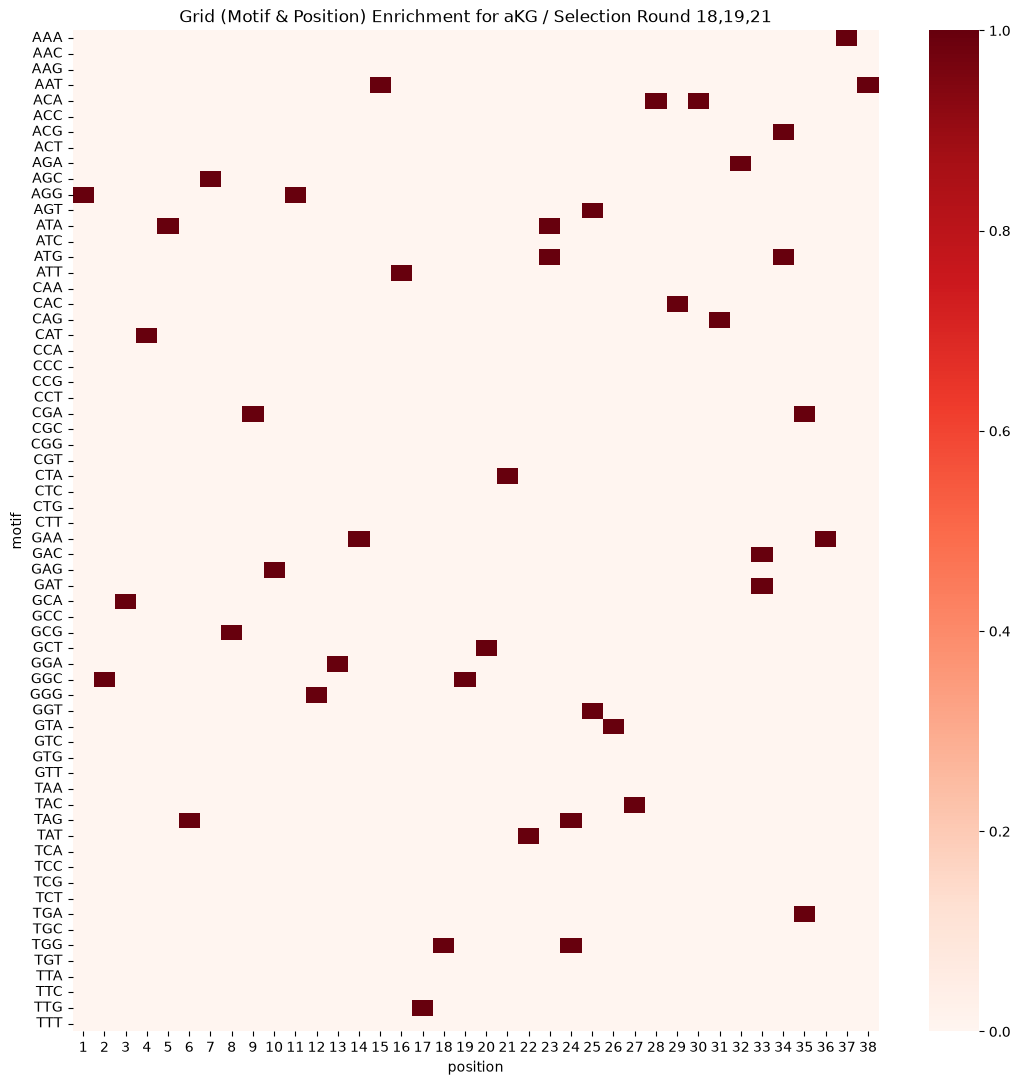

In [20]:
plt.figure(figsize=(13, 13))
# 2D heatmap
sns.heatmap(
    df_direction_2d,
    cmap="Reds",
)
plt.title(
    f"Grid (Motif & Position) Enrichment for {sample} / Selection Round {rounds[0]},{rounds[1]},{rounds[2]}"
)

plt.savefig(
    f"{DIR}/Enrichment/{sample}/{Deduplication}/{sample}_GridEnrichment_2D_Heatmap_{Deduplication}.png",
    dpi=200,
)